<a href="https://colab.research.google.com/github/Oct-o-Dev/DL/blob/main/EWMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
import kagglehub
import os

# 1. Download the dataset
path = kagglehub.dataset_download("sukhmandeepsinghbrar/daily-delhi-climate")
print("Path to dataset directory:", path)

# 2. Check the files inside (this told us the real name)
files = os.listdir(path)
print("Files in this folder:", files)

# 3. Join the path using the CORRECT file name
csv_file_path = os.path.join(path, "DailyDelhiClimate.csv")

# 4. Read the CSV and display
df = pd.read_csv(csv_file_path)
print(df.head())

Using Colab cache for faster access to the 'daily-delhi-climate' dataset.
Path to dataset directory: /kaggle/input/daily-delhi-climate
Files in this folder: ['DailyDelhiClimate.csv']
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [6]:
df = df[['date' , 'meantemp']]
df

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000
...,...,...
1571,2017-04-20,34.500000
1572,2017-04-21,34.250000
1573,2017-04-22,32.900000
1574,2017-04-23,32.875000


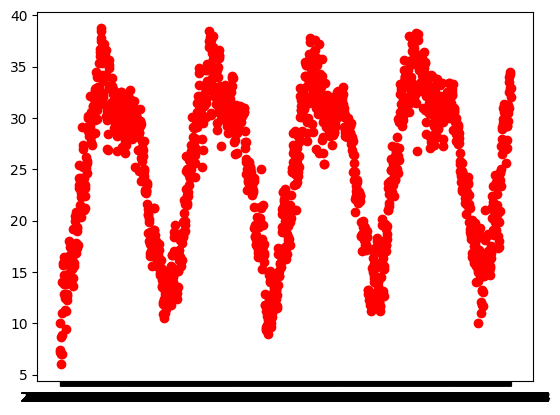

In [7]:
plt.scatter(df['date'] , df['meantemp'] , color='red')

In [13]:
x1 = df['meantemp'].ewm(alpha=0.2).mean()

In [14]:
x1

,meantemp
0,10.000000
1,8.555556
2,7.986339
3,8.216802
4,7.557354
...,...
1571,32.177088
1572,32.591670
1573,32.653336
1574,32.697669


In [15]:
df['ewma'] = x1

In [16]:
df

,date,meantemp,ewma
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,8.555556
2,2013-01-03,7.166667,7.986339
3,2013-01-04,8.666667,8.216802
4,2013-01-05,6.000000,7.557354
...,...,...,...
1571,2017-04-20,34.500000,32.177088
1572,2017-04-21,34.250000,32.591670
1573,2017-04-22,32.900000,32.653336
1574,2017-04-23,32.875000,32.697669


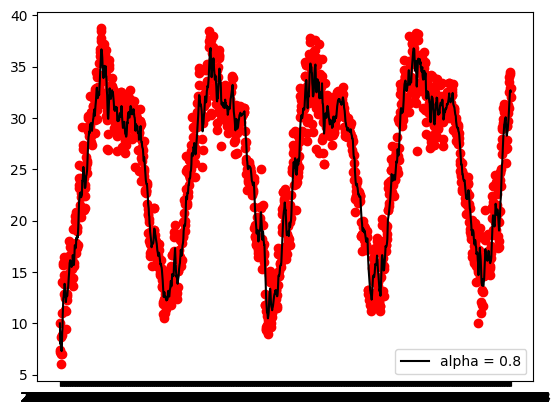

In [18]:
plt.scatter(df['date'] , df['meantemp'] , color='red')
plt.plot(df['date'],x1,color='black' , label='alpha = 0.8')
plt.legend()
plt.show()